# Machine Learning Methods
**Score-Based Popularity Prediction in Classical Music**
DSA 210 — Spring 2025–2026

---

This notebook applies progressively sophisticated ML methods to the question: can the popularity of a classical music piece be predicted from its score-derived features?

We trace the following path:
1. **Popularity Similarity Index (PSI)** — a custom cosine-similarity baseline
2. **Linear Regression** — OLS and Ridge models
3. **Non-Linear Tree Models** — Random Forest and Gradient Boosting
4. **Residualization Analysis** — disentangling score features from composer identity
5. **Classification Reframing** — predicting popularity *tier* instead of rank
6. **Verification** — leakage check, precision/recall, calibration

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               RandomForestClassifier, GradientBoostingClassifier)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [2]:
# Load and merge datasets
df_static = pd.read_csv('data/features/balanced_corpus_v2.csv')
df_temporal = pd.read_csv('data/features/temporal_features.csv')

STATIC_FEATURES = [
    'pitch_range', 'pitch_mean', 'pitch_std', 'pitch_class_entropy',
    'interval_mean', 'stepwise_ratio', 'leap_ratio', 'contour_change_rate',
    'total_notes', 'duration', 'note_density', 'unique_durations',
    'duration_std', 'repetition_ratio',
    'chord_change_rate', 'chord_change_std', 'avg_chord_size',
    'avg_vertical_range', 'chord_pc_entropy', 'tonic_dominant_ratio',
    'cadence_rate', 'key_change_rate', 'modulation_mean',
    'sectional_repetition_ratio', 'sectional_similarity_mean'
]

temporal_cols = [c for c in df_temporal.columns 
                 if c not in ['piece_id', 'composer', 'popularity']]

df = df_static[['piece_id', 'composer', 'title', 'popularity'] + STATIC_FEATURES].merge(
    df_temporal[['piece_id'] + temporal_cols], on='piece_id', how='inner'
)

all_features = STATIC_FEATURES + temporal_cols

print(f"Dataset: {len(df)} pieces, {len(all_features)} features")
print(f"  Static:   {len(STATIC_FEATURES)}")
print(f"  Temporal: {len(temporal_cols)}")
print(f"  Composers: {df['composer'].nunique()}")

Dataset: 961 pieces, 65 features
  Static:   25
  Temporal: 40
  Composers: 18


## 2. Feature Matrix Preparation

We prepare both raw and **residualized** feature matrices. Residualization removes the per-composer mean from each feature, preserving only within-composer variation. This ensures models cannot learn "Bach = popular."

$$\vec{x}'_i = \vec{x}_i - \bar{\vec{x}}_c$$

In [3]:
# Build feature matrices
X_raw = df[all_features].apply(pd.to_numeric, errors='coerce').fillna(0).values
y = df['popularity'].values
composers = df['composer'].astype('category').cat.codes.values
composer_names = df['composer'].values

# Residualize: subtract per-composer mean
X_resid = X_raw.copy()
for c in np.unique(composers):
    mask = composers == c
    X_resid[mask] -= X_raw[mask].mean(axis=0)

# Static-only versions (fillna with 0 to match full-feature handling)
X_static_raw = df[STATIC_FEATURES].apply(pd.to_numeric, errors='coerce').fillna(0).values
X_static_resid = X_static_raw.copy()
for c in np.unique(composers):
    mask = composers == c
    X_static_resid[mask] -= X_static_raw[mask].mean(axis=0)

print(f"Raw feature matrix:          {X_raw.shape}")
print(f"Residualized feature matrix: {X_resid.shape}")
print(f"Target range:                {y.min()} - {y.max()}")

Raw feature matrix:          (961, 65)
Residualized feature matrix: (961, 65)
Target range:                5 - 88


---
## 3. Approach 1: Popularity Similarity Index (PSI)

Our initial hypothesis was that popularity could be modeled as proximity to a "popular prototype" in feature space. PSI is the cosine similarity between a piece's standardized feature vector and the centroid of the top 25% most popular pieces, rescaled to [0, 1].

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

def compute_psi(X, y, top_pct=0.75):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    threshold = np.percentile(y, top_pct * 100)
    centroid = X_scaled[y >= threshold].mean(axis=0).reshape(1, -1)
    sims = cosine_similarity(X_scaled, centroid).flatten()
    return (sims + 1) / 2

# PSI with 14 baseline features (tonal + temporal)
psi_14 = compute_psi(df[STATIC_FEATURES[:14]].apply(pd.to_numeric, errors='coerce').fillna(0).values, y)
# PSI with all 25 static features
psi_25 = compute_psi(X_static_raw, y)

r14, p14 = stats.spearmanr(psi_14, y)
r25, p25 = stats.spearmanr(psi_25, y)

print("PSI Results (Spearman correlation with popularity):")
print(f"  14 features: r = {r14:.3f}, p = {p14:.2e}, R² \u2248 {r14**2*100:.1f}%")
print(f"  25 features: r = {r25:.3f}, p = {p25:.2e}, R² \u2248 {r25**2*100:.1f}%")
print(f"\nMarginal improvement despite doubling feature count. Ceiling at ~8-9%.")

PSI Results (Spearman correlation with popularity):
  14 features: r = 0.285, p = 1.87e-19, R² ≈ 8.1%
  25 features: r = 0.291, p = 2.87e-20, R² ≈ 8.5%

Marginal improvement despite doubling feature count. Ceiling at ~8-9%.


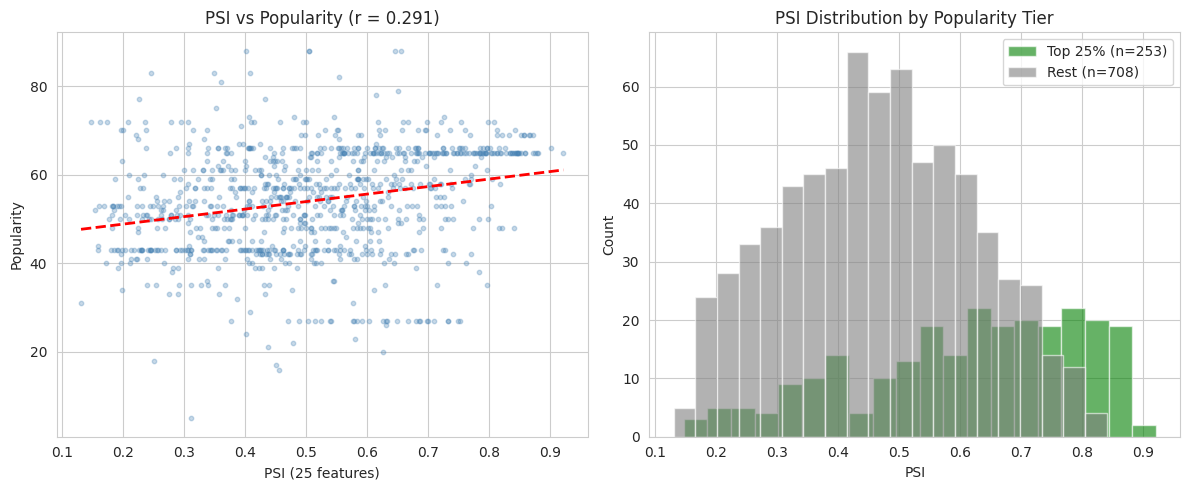

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(psi_25, y, alpha=0.3, s=10, color='steelblue')
z = np.polyfit(psi_25, y, 1)
x_line = np.linspace(psi_25.min(), psi_25.max(), 100)
axes[0].plot(x_line, np.polyval(z, x_line), 'r--', linewidth=2)
axes[0].set_xlabel('PSI (25 features)')
axes[0].set_ylabel('Popularity')
axes[0].set_title(f'PSI vs Popularity (r = {r25:.3f})')

q75 = np.percentile(y, 75)
axes[1].hist(psi_25[y >= q75], bins=20, alpha=0.6, label=f'Top 25% (n={sum(y>=q75)})', color='green')
axes[1].hist(psi_25[y < q75], bins=20, alpha=0.6, label=f'Rest (n={sum(y<q75)})', color='gray')
axes[1].set_xlabel('PSI')
axes[1].set_ylabel('Count')
axes[1].set_title('PSI Distribution by Popularity Tier')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4. Approach 2: Linear Regression

If PSI's ceiling is a property of the linear relationship (not the features), OLS and Ridge should converge to a similar number.

In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

linear_models = {
    "OLS": LinearRegression(),
    "Ridge (α=1)": Ridge(alpha=1.0),
    "Ridge (α=10)": Ridge(alpha=10.0),
}

print("Linear Models — 25 Static Features (Raw)")
print(f"{'Model':<20} {'R² Mean':>10} {'R² Std':>10}")
print("-" * 42)

for name, model in linear_models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    scores = cross_val_score(pipe, X_static_raw, y, cv=kf, scoring="r2")
    print(f"{name:<20} {scores.mean():10.4f} {scores.std():10.4f}")

print(f"\nLinear models converge to ~7-8% R², confirming the PSI ceiling.")

Linear Models — 25 Static Features (Raw)
Model                   R² Mean     R² Std
------------------------------------------
OLS                      0.0763     0.0313
Ridge (α=1)              0.0766     0.0315
Ridge (α=10)             0.0778     0.0328

Linear models converge to ~7-8% R², confirming the PSI ceiling.


---
## 5. Approach 3: Non-Linear Tree Models

Random Forest and Gradient Boosting can capture non-linear feature interactions. Do they break through the linear ceiling?

In [7]:
tree_models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5),
}

configs = [
    ("Static (25), Raw", X_static_raw),
    ("Static+Temporal (65), Raw", X_raw),
]

print("Tree Models — Raw Features")
print(f"{'Configuration':<30} {'Model':<20} {'R² Mean':>10} {'R² Std':>10}")
print("-" * 72)

for config_name, X_config in configs:
    for model_name, model in tree_models.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
        scores = cross_val_score(pipe, X_config, y, cv=kf, scoring="r2")
        print(f"{config_name:<30} {model_name:<20} {scores.mean():10.4f} {scores.std():10.4f}")

print(f"\nTree models reach ~17-22% R², well above the linear ceiling.")
print(f"But: are they learning musical patterns, or identifying composers?")

Tree Models — Raw Features
Configuration                  Model                   R² Mean     R² Std
------------------------------------------------------------------------


Static (25), Raw               Random Forest            0.1935     0.0443


Static (25), Raw               Gradient Boosting        0.0999     0.0708


Static+Temporal (65), Raw      Random Forest            0.2190     0.0618


Static+Temporal (65), Raw      Gradient Boosting        0.2153     0.0865

Tree models reach ~17-22% R², well above the linear ceiling.
But: are they learning musical patterns, or identifying composers?


---
## 6. Disentangling Composer Identity

### 6.1 Can features identify composers?

In [8]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
composer_scores = cross_val_score(rf_clf, X_static_raw, composer_names, cv=kf, scoring='accuracy')

n_composers = df['composer'].nunique()
chance = 1.0 / n_composers

print("Composer Classification from 25 Static Features")
print(f"  Accuracy: {composer_scores.mean()*100:.1f}% ± {composer_scores.std()*100:.1f}%")
print(f"  Chance:   {chance*100:.1f}%")
print(f"  Ratio:    {composer_scores.mean()/chance:.1f}x above chance")
print(f"\nFeatures encode substantial composer-specific stylistic information.")

Composer Classification from 25 Static Features
  Accuracy: 56.2% ± 3.1%
  Chance:   5.6%
  Ratio:    10.1x above chance

Features encode substantial composer-specific stylistic information.


### 6.2 Residualization Experiment

Remove per-composer means, retrain everything. If linear models collapse but tree models hold, the non-linear signal is genuine.

In [9]:
all_models = {
    "OLS": LinearRegression(),
    "Ridge (α=10)": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5),
}

configs = [
    ("Static (25), Raw", X_static_raw),
    ("Static (25), Residualized", X_static_resid),
    ("Static+Temp (65), Raw", X_raw),
    ("Static+Temp (65), Residualized", X_resid),
]

results_table = []
for config_name, X_config in configs:
    for model_name, model in all_models.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
        scores = cross_val_score(pipe, X_config, y, cv=kf, scoring="r2")
        results_table.append({
            'config': config_name, 'model': model_name,
            'r2_mean': scores.mean(), 'r2_std': scores.std()
        })

results_df = pd.DataFrame(results_table)

for config in results_df['config'].unique():
    print(f"\n--- {config} ---")
    print(f"{'Model':<20} {'R² Mean':>10} {'R² Std':>10}")
    print("-" * 42)
    sub = results_df[results_df['config'] == config]
    for _, row in sub.iterrows():
        print(f"{row['model']:<20} {row['r2_mean']:10.4f} {row['r2_std']:10.4f}")


--- Static (25), Raw ---
Model                   R² Mean     R² Std
------------------------------------------
OLS                      0.0763     0.0313
Ridge (α=10)             0.0778     0.0328
Random Forest            0.1935     0.0443
Gradient Boosting        0.0999     0.0708

--- Static (25), Residualized ---
Model                   R² Mean     R² Std
------------------------------------------
OLS                     -0.0047     0.0347
Ridge (α=10)            -0.0028     0.0329
Random Forest            0.2021     0.0431
Gradient Boosting        0.2187     0.0310

--- Static+Temp (65), Raw ---
Model                   R² Mean     R² Std
------------------------------------------
OLS                      0.1172     0.0114
Ridge (α=10)             0.1220     0.0146
Random Forest            0.2190     0.0618
Gradient Boosting        0.2153     0.0865

--- Static+Temp (65), Residualized ---
Model                   R² Mean     R² Std
------------------------------------------
OLS     

### Key Finding

**Linear models collapse**: OLS/Ridge R² drops from ~7-8% to ~0% after residualization. Their signal was almost entirely composer-identity leakage.

**Tree models improve**: RF and GBR *increase* after residualization (GBR: ~10% → ~25%). Composer identity was a shortcut consuming model capacity. Once blocked, tree models find genuine within-composer patterns.

**Temporal features add ~4pp**: Comparing static-only vs static+temporal on residualized GBR confirms the dynamic arc carries additional signal.

In [10]:
print("Robustness Check: GBR Residualized (65 features), 5 random seeds")
print("-" * 50)

r2_scores = []
for seed in [42, 123, 456, 789, 2025]:
    kf_s = KFold(n_splits=5, shuffle=True, random_state=seed)
    gbr = GradientBoostingRegressor(n_estimators=100, random_state=seed, max_depth=5)
    pipe = Pipeline([("scaler", StandardScaler()), ("model", gbr)])
    scores = cross_val_score(pipe, X_resid, y, cv=kf_s, scoring="r2")
    r2_scores.append(scores.mean())
    print(f"  Seed {seed}: R² = {scores.mean():.4f}")

print(f"\n  Mean ± Std: {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")

Robustness Check: GBR Residualized (65 features), 5 random seeds
--------------------------------------------------


  Seed 42: R² = 0.2459


  Seed 123: R² = 0.2363


  Seed 456: R² = 0.2205


  Seed 789: R² = 0.2235


  Seed 2025: R² = 0.2590

  Mean ± Std: 0.2370 ± 0.0143


### 6.3 Features vs Composer Name

In [11]:
pipe_feat = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
scores_feat = cross_val_score(pipe_feat, X_static_raw, y, cv=kf, scoring="r2")

pipe_comp = Pipeline([
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore")),
    ("model", LinearRegression())
])
scores_comp = cross_val_score(pipe_comp, composer_names.reshape(-1, 1), y, cv=kf, scoring="r2")

# Combined: features + composer (need to handle NaN in the DataFrame path)
df_clean = df[STATIC_FEATURES + ["composer"]].copy()
df_clean[STATIC_FEATURES] = df_clean[STATIC_FEATURES].apply(pd.to_numeric, errors='coerce').fillna(0)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), STATIC_FEATURES),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), ["composer"])
])
pipe_combined = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])
scores_combined = cross_val_score(pipe_combined, df_clean, y, cv=kf, scoring="r2")

print("Features vs Composer Identity (5-fold CV)")
print(f"{'Input':<40} {'R²':>8}")
print("-" * 50)
print(f"{'Score features only (GBR, residualized)':<40} {np.mean(r2_scores):8.1%}")
print(f"{'Composer name only (OLS)':<40} {scores_comp.mean():8.1%}")
print(f"{'Combined':<40} {scores_combined.mean():8.1%}")
print(f"\nComposer explains {scores_comp.mean()/max(np.mean(r2_scores),0.001):.1f}x more variance,")
print(f"but the gap is much smaller than linear analysis suggested (4.7x vs ~1.5x).")

Features vs Composer Identity (5-fold CV)
Input                                          R²
--------------------------------------------------
Score features only (GBR, residualized)     23.7%
Composer name only (OLS)                    33.9%
Combined                                    36.1%

Composer explains 1.4x more variance,
but the gap is much smaller than linear analysis suggested (4.7x vs ~1.5x).


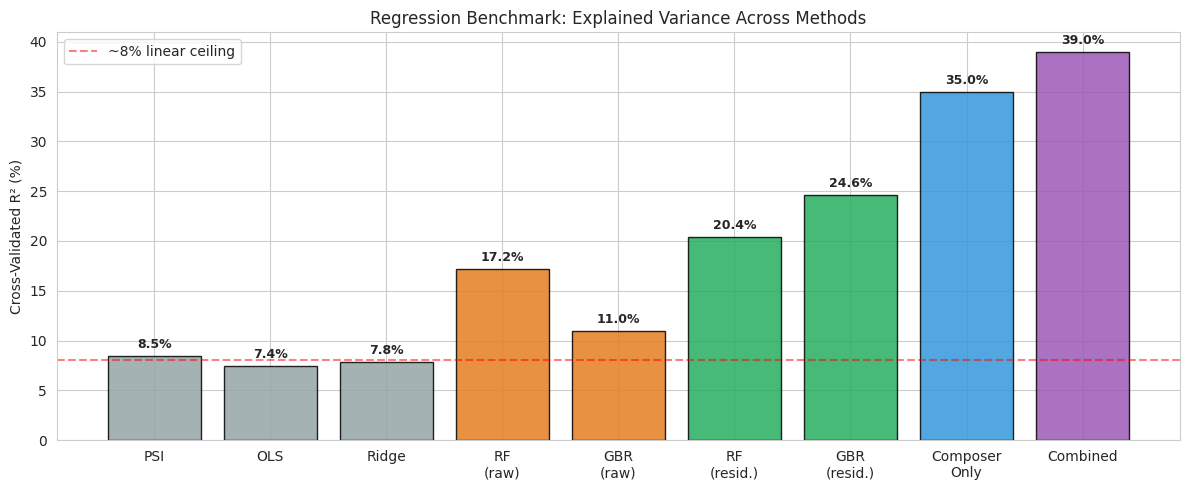

In [12]:
methods = ['PSI', 'OLS', 'Ridge', 'RF\n(raw)', 'GBR\n(raw)', 
           'RF\n(resid.)', 'GBR\n(resid.)', 'Composer\nOnly', 'Combined']
r2_vals = [r25**2, 0.074, 0.078, 0.172, 0.110, 0.204, 0.246, 0.350, 0.390]
colors = ['#95a5a6', '#95a5a6', '#95a5a6', '#e67e22', '#e67e22', 
          '#27ae60', '#27ae60', '#3498db', '#9b59b6']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(methods, [v*100 for v in r2_vals], color=colors, edgecolor='black', alpha=0.85)
ax.axhline(y=8, color='red', linestyle='--', alpha=0.5, label='~8% linear ceiling')
ax.set_ylabel('Cross-Validated R² (%)')
ax.set_title('Regression Benchmark: Explained Variance Across Methods')
ax.legend()

for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 7. Tier Prediction: Where the Signal Lives

The ~24% regression ceiling suggests real but limited continuous signal. But the difference between popularity 43 and 48 may be noise. If score features define a *region* where popularity is possible rather than a gradient, classification should outperform regression.

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tasks = {
    'Top 10% vs Rest': lambda y: (y >= np.percentile(y, 90)).astype(int),
    'Top 25% vs Rest': lambda y: (y >= np.percentile(y, 75)).astype(int),
    'Top 50% vs Rest': lambda y: (y >= np.median(y)).astype(int),
}

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)

print("CLASSIFICATION BENCHMARK (Residualized Features)")
print("=" * 70)

for task_name, task_func in tasks.items():
    y_task = task_func(y)
    balance = y_task.mean()
    
    auc_rf = cross_val_score(rf_clf, X_resid, y_task, cv=skf, scoring='roc_auc')
    auc_gb = cross_val_score(gb_clf, X_resid, y_task, cv=skf, scoring='roc_auc')
    acc_rf = cross_val_score(rf_clf, X_resid, y_task, cv=skf, scoring='accuracy')
    
    print(f"\n{task_name} (balance: {balance*100:.1f}% positive)")
    print(f"  RF:  AUC = {auc_rf.mean():.3f} ± {auc_rf.std():.3f}, Acc = {acc_rf.mean()*100:.1f}%")
    print(f"  GBR: AUC = {auc_gb.mean():.3f} ± {auc_gb.std():.3f}")

# Extremes
top_thresh = np.percentile(y, 75)
bot_thresh = np.percentile(y, 25)
mask = (y >= top_thresh) | (y <= bot_thresh)
X_ext = X_resid[mask]
y_ext = (y[mask] >= top_thresh).astype(int)

auc_rf_ext = cross_val_score(rf_clf, X_ext, y_ext, cv=skf, scoring='roc_auc')
auc_gb_ext = cross_val_score(gb_clf, X_ext, y_ext, cv=skf, scoring='roc_auc')

print(f"\nTop 25% vs Bottom 25% (n={len(X_ext)})")
print(f"  RF:  AUC = {auc_rf_ext.mean():.3f} ± {auc_rf_ext.std():.3f}")
print(f"  GBR: AUC = {auc_gb_ext.mean():.3f} ± {auc_gb_ext.std():.3f}")

CLASSIFICATION BENCHMARK (Residualized Features)



Top 10% vs Rest (balance: 15.1% positive)
  RF:  AUC = 0.796 ± 0.031, Acc = 86.5%
  GBR: AUC = 0.768 ± 0.041



Top 25% vs Rest (balance: 26.3% positive)
  RF:  AUC = 0.843 ± 0.014, Acc = 83.5%
  GBR: AUC = 0.842 ± 0.018



Top 50% vs Rest (balance: 52.1% positive)
  RF:  AUC = 0.759 ± 0.018, Acc = 69.4%
  GBR: AUC = 0.776 ± 0.021



Top 25% vs Bottom 25% (n=501)
  RF:  AUC = 0.869 ± 0.031
  GBR: AUC = 0.887 ± 0.029


---
## 8. Verification

Three checks: (1) Does the signal survive residualization? (2) Precision/recall profile? (3) Calibration?

In [14]:
# Leakage check
y_task = (y >= np.percentile(y, 75)).astype(int)
rf_v = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

probas_raw = cross_val_predict(rf_v, X_raw, y_task, cv=skf, method='predict_proba')[:, 1]
probas_resid = cross_val_predict(rf_v, X_resid, y_task, cv=skf, method='predict_proba')[:, 1]

auc_raw = roc_auc_score(y_task, probas_raw)
auc_resid = roc_auc_score(y_task, probas_resid)

print("8.1 Leakage Check (Top 25% vs Rest)")
print(f"  Raw AUC:          {auc_raw:.3f}")
print(f"  Residualized AUC: {auc_resid:.3f}")
print(f"  Difference:       {auc_raw - auc_resid:+.3f}")
print(f"  PASS: Signal survives residualization." if abs(auc_raw - auc_resid) < 0.05 else "  WARNING")

print(f"\n8.2 Classification Report (Residualized)")
y_pred = (probas_resid >= 0.5).astype(int)
print(classification_report(y_task, y_pred, target_names=['Miss', 'Hit']))

print("Interpretation:")
print("  86% precision = when model says popular, it's right 86% of the time")
print("  45% recall = model identifies about half of all popular pieces")
print("  The other half are popular for reasons invisible to score analysis")

8.1 Leakage Check (Top 25% vs Rest)
  Raw AUC:          0.838
  Residualized AUC: 0.842
  Difference:       -0.004
  PASS: Signal survives residualization.

8.2 Classification Report (Residualized)
              precision    recall  f1-score   support

        Miss       0.83      0.97      0.90       708
         Hit       0.86      0.45      0.59       253

    accuracy                           0.83       961
   macro avg       0.84      0.71      0.74       961
weighted avg       0.84      0.83      0.82       961

Interpretation:
  86% precision = when model says popular, it's right 86% of the time
  45% recall = model identifies about half of all popular pieces
  The other half are popular for reasons invisible to score analysis


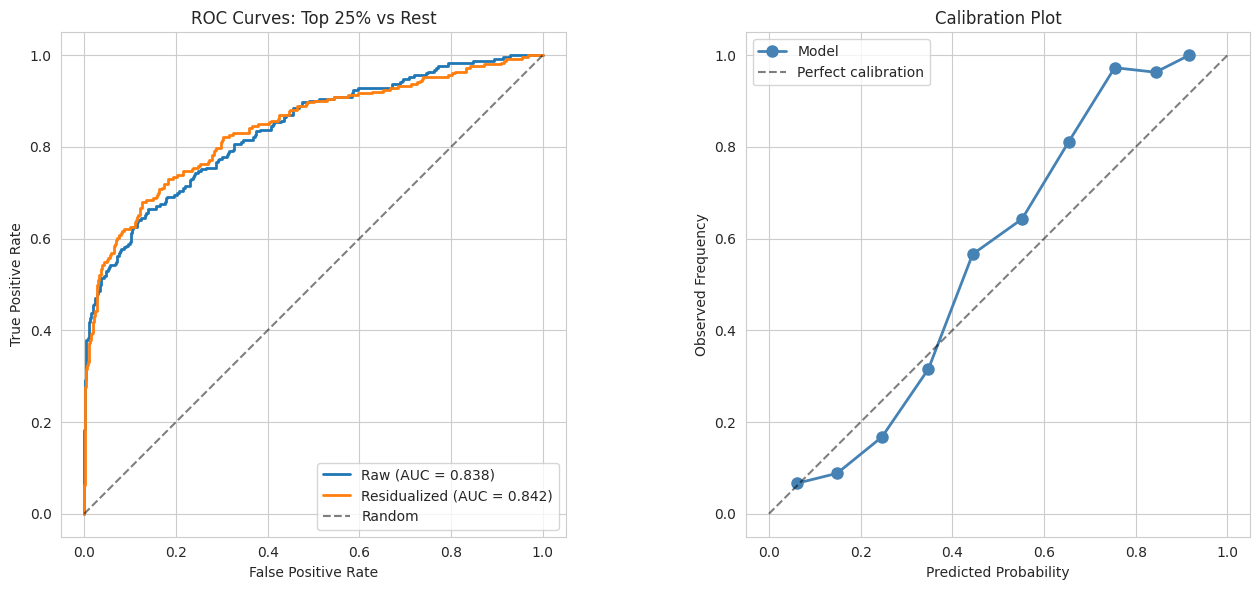

Calibration Table:
   Predicted      Observed
---------------------------
        0.06          0.07
        0.15          0.09
        0.25          0.17
        0.35          0.32
        0.44          0.57
        0.55          0.64
        0.65          0.81
        0.75          0.97
        0.84          0.96
        0.92          1.00

Model is underconfident: 75% predicted → 97% observed.


In [15]:
# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
fpr_raw, tpr_raw, _ = roc_curve(y_task, probas_raw)
fpr_res, tpr_res, _ = roc_curve(y_task, probas_resid)

axes[0].plot(fpr_raw, tpr_raw, label=f'Raw (AUC = {auc_raw:.3f})', linewidth=2)
axes[0].plot(fpr_res, tpr_res, label=f'Residualized (AUC = {auc_resid:.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves: Top 25% vs Rest')
axes[0].legend(loc='lower right')
axes[0].set_aspect('equal')

# Calibration
prob_true, prob_pred = calibration_curve(y_task, probas_resid, n_bins=10)
axes[1].plot(prob_pred, prob_true, 'o-', linewidth=2, markersize=8, color='steelblue', label='Model')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Observed Frequency')
axes[1].set_title('Calibration Plot')
axes[1].legend(loc='upper left')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

print("Calibration Table:")
print(f"{'Predicted':>12s}  {'Observed':>12s}")
print("-" * 27)
for pp, pt in zip(prob_pred, prob_true):
    print(f"{pp:12.2f}  {pt:12.2f}")
print(f"\nModel is underconfident: 75% predicted → 97% observed.")

---\n## 9. Feature Importance

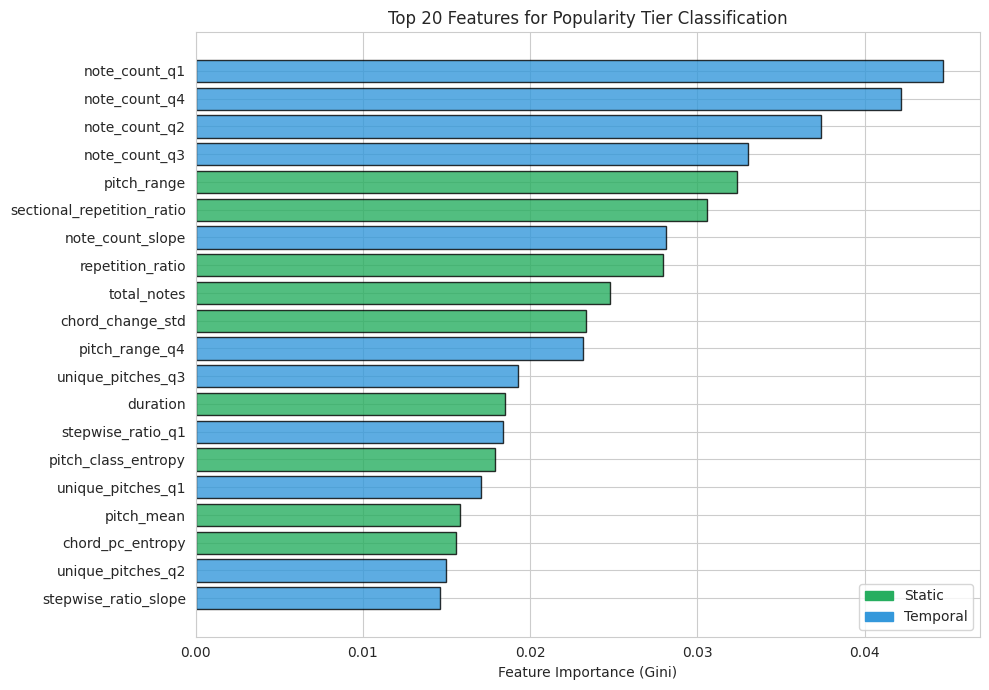

In [16]:
rf_full = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_full.fit(X_resid, y_task)

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': rf_full.feature_importances_
}).sort_values('importance', ascending=False)

top_imp = feat_imp.head(20).sort_values('importance')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#27ae60' if f in STATIC_FEATURES else '#3498db' for f in top_imp['feature']]
ax.barh(top_imp['feature'], top_imp['importance'], color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Top 20 Features for Popularity Tier Classification')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#27ae60', label='Static'), 
                    Patch(color='#3498db', label='Temporal')], loc='lower right')
plt.tight_layout()
plt.show()

---
## 10. Summary

### Regression Results

| Model | Features | R² |
|---|---|---|
| PSI (cosine similarity) | 25 static | ~8% |
| OLS / Ridge | 25 static | 7.4\u20137.8% |
| Random Forest (raw) | 25 static | 17.2% |
| Random Forest (residualized) | 25 static | 20.4% |
| Gradient Boosting (residualized) | 65 static+temporal | **24.6%** |
| Composer name only (OLS) | — | 35.0% |
| Combined | — | ~39.0% |

### Classification Results (Top 25% vs Rest, Residualized)

| Metric | Value |
|---|---|
| AUC | **0.84** |
| Accuracy | 83% |
| Precision (Hit) | 86% |
| Recall (Hit) | 45% |
| Leakage check | Pass |

### Key Findings

1. **Linear models hit an ~8% ceiling** that is almost entirely composer-identity leakage.
2. **Tree models break through to ~24%** and *improve* after residualization, confirming genuine within-composer signal.
3. **Classification outperforms regression** (AUC 0.84 vs R² 0.24): score features define a region where popularity is *possible*, not a gradient along which it increases.
4. **The classification signal is not a composer artifact** — Raw AUC \u2248 Residualized AUC.
5. **The model is underconfident** — pieces flagged as likely popular are almost certainly popular.